First 5 rows:
  CropType  CropDays  SoilMoisture  temperature  Humidity  Irrigation
0    Wheat        10           400           30        15           0
1    Wheat         7           200           30        32           0
2    Wheat         9           300           21        28           0
3    Wheat         3           500           40        22           0
4    Wheat         2           700           23        34           0 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CropType      501 non-null    object
 1   CropDays      501 non-null    int64 
 2   SoilMoisture  501 non-null    int64 
 3   temperature   501 non-null    int64 
 4   Humidity      501 non-null    int64 
 5   Irrigation    501 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 23.6+ KB
None 

Summary Statistics:
         CropDays  SoilMoisture 

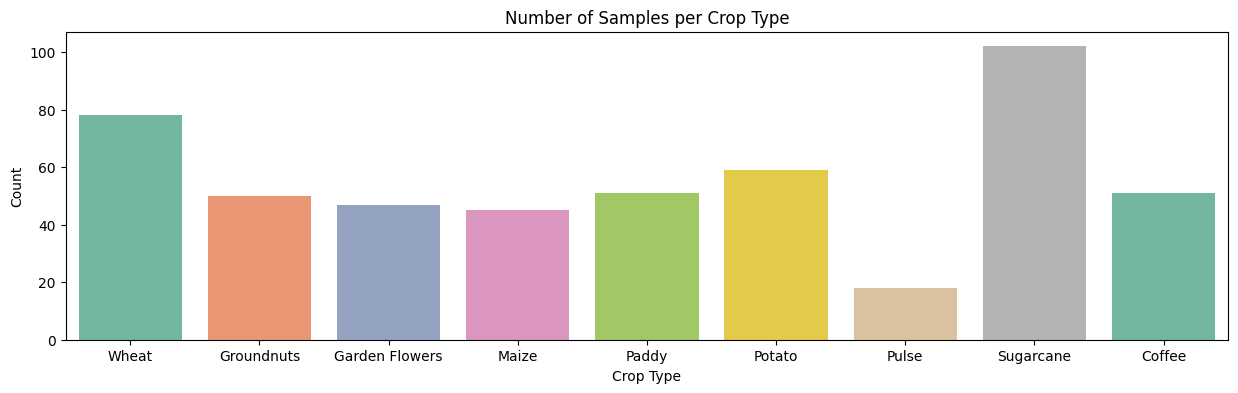

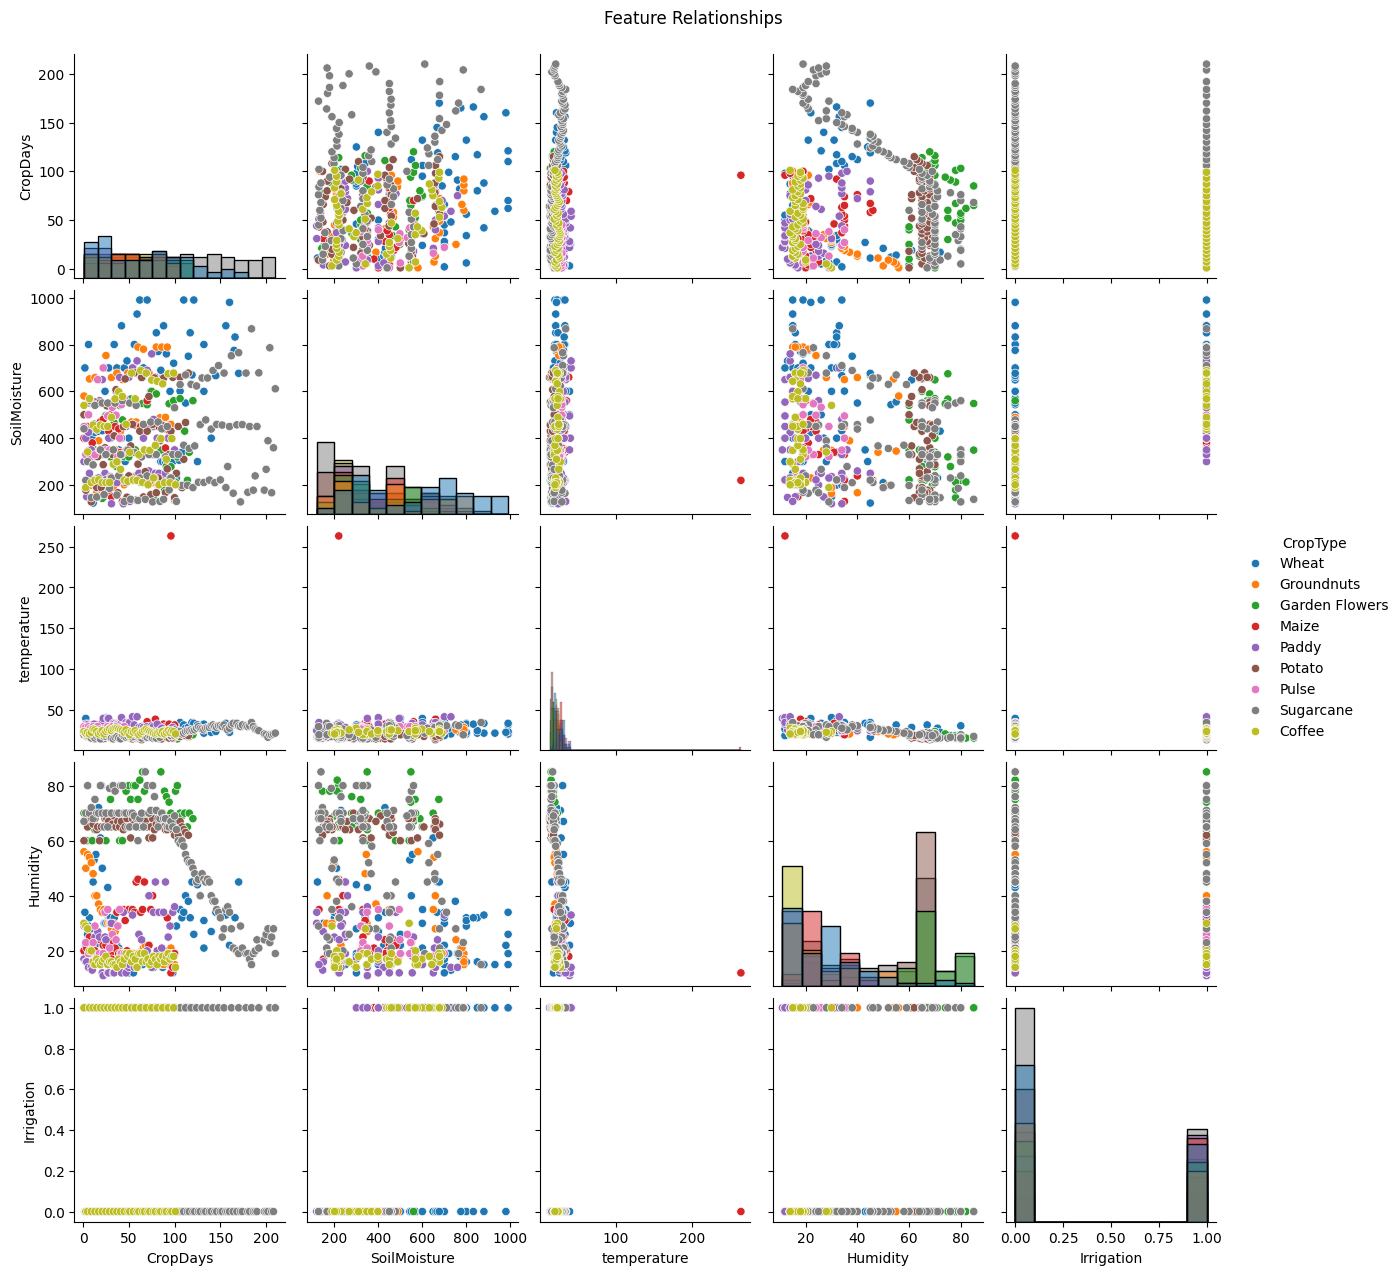

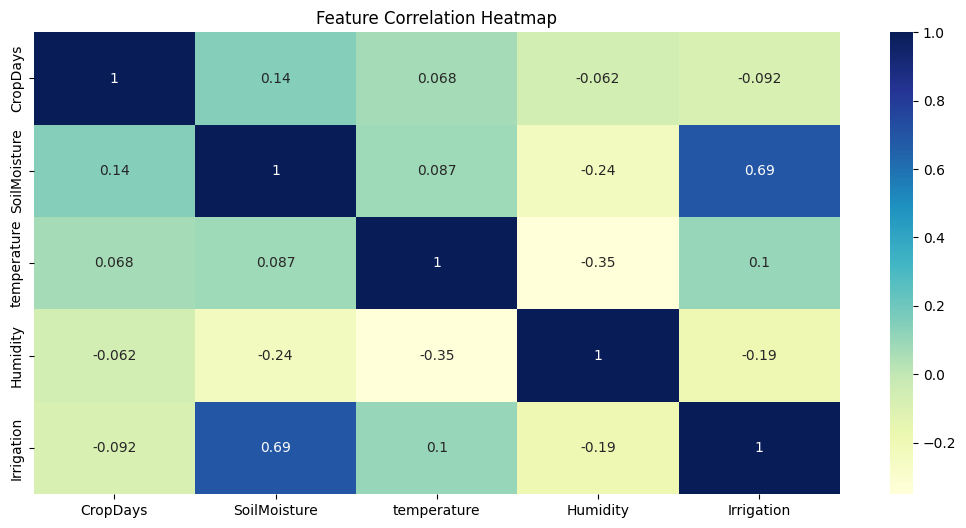

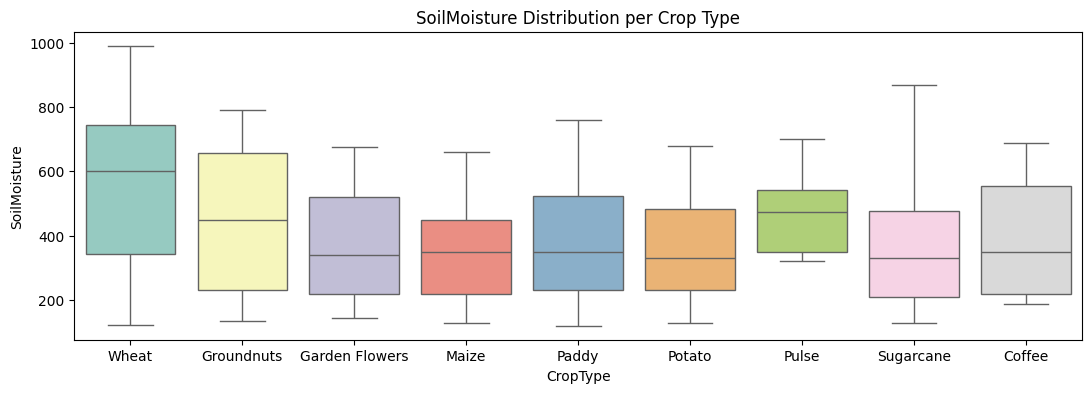

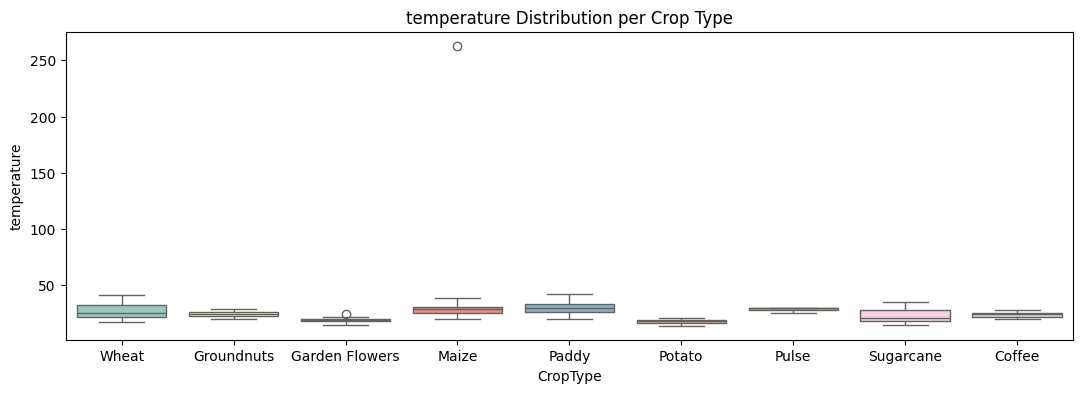

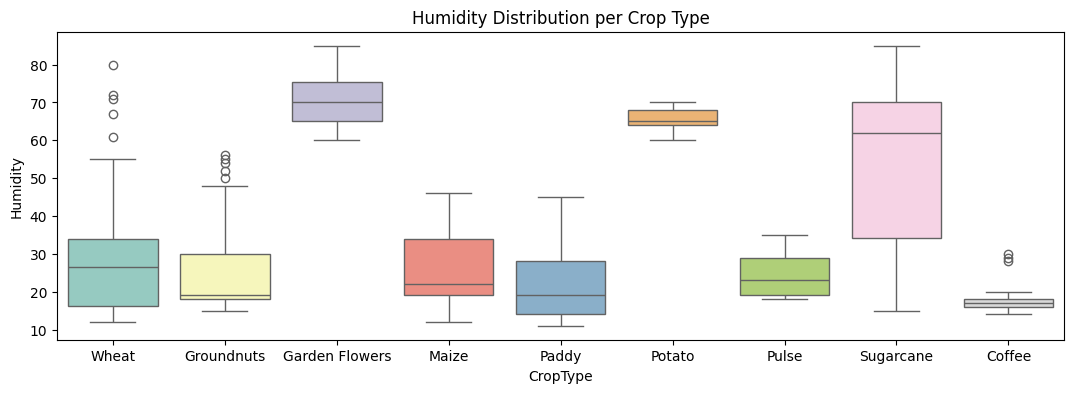

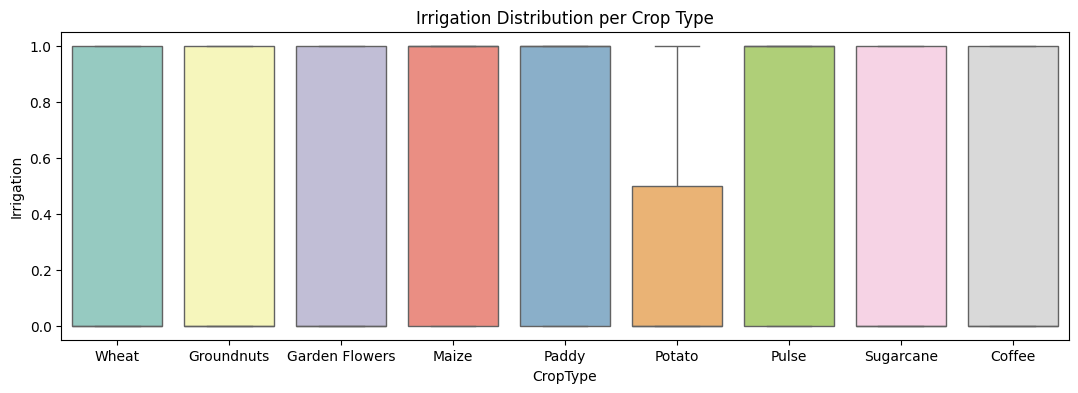

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("data_smart.csv")

# --- Display basic info ---
print("First 5 rows:")
print(data.head(), "\n")

print("Dataset Info:")
print(data.info(), "\n")

print("Summary Statistics:")
print(data.describe(), "\n")

# --- Check for missing values ---
print("Missing Values:")
print(data.isnull().sum(), "\n")

# --- Check unique crop types ---
print("Unique Crop Types:")
print(data['CropType'].unique(), "\n")

# --- Class distribution ---
plt.figure(figsize=(15,4))
sns.countplot(x='CropType', hue='CropType', data=data, palette='Set2', legend=False)  # ✅ fixed warning
plt.title("Number of Samples per Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

# --- Pairplot to see feature relationships ---
sns.pairplot(data, hue='CropType', diag_kind='hist')
plt.suptitle("Feature Relationships", y=1.02)
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(13,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title("Feature Correlation Heatmap")
plt.show()

# --- Boxplots to check distributions per crop ---
features = ['SoilMoisture', 'temperature', 'Humidity', 'Irrigation']

for feature in features:
    plt.figure(figsize=(13,4))
    sns.boxplot(x='CropType', y=feature, hue='CropType', data=data, palette='Set3', dodge=False, legend=False)
    plt.title(f"{feature} Distribution per Crop Type")
    plt.show()



Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1382 - loss: 2.1647 - val_accuracy: 0.2277 - val_loss: 2.0925
Epoch 2/70
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2132 - loss: 2.0419 - val_accuracy: 0.2574 - val_loss: 1.9835
Epoch 3/70
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2591 - loss: 1.9700 - val_accuracy: 0.2772 - val_loss: 1.8647
Epoch 4/70
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3182 - loss: 1.8627 - val_accuracy: 0.3465 - val_loss: 1.7492
Epoch 5/70
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2935 - loss: 1.6809 - val_accuracy: 0.3762 - val_loss: 1.6507
Epoch 6/70
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3513 - loss: 1.5925 - val_accuracy: 0.3366 - val_loss: 1.5915
Epoch 7/70
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3546 - loss: 1.5838 - val_accuracy: 0.3366 - val_loss: 1.5728
Epoch 8/70
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3654 - loss: 1.5223 - val_accuracy: 0.3465 - val_loss: 1.5487
Ep

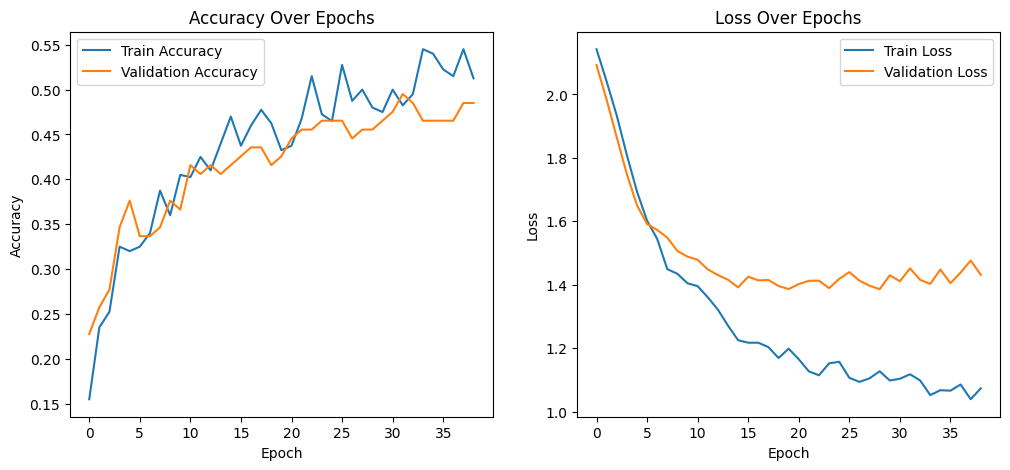

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Crop Type: Wheat


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# --- 1️⃣ Load dataset ---
data = pd.read_csv("data_smart.csv")

# --- 2️⃣ Features and target ---
X = data[['CropDays', 'SoilMoisture', 'temperature', 'Humidity', 'Irrigation']]
y = data['CropType']

# --- 3️⃣ Encode target labels ---
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# --- 4️⃣ Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 5️⃣ Train/test split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- 6️⃣ Build improved MLP model ---
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # prevent overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(len(encoder.classes_), activation='softmax')  # output = number of crop classes
])

# --- 7️⃣ Compile model ---
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)  # smaller learning rate
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# --- 8️⃣ Early stopping ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# --- 9️⃣ Train model ---
history = model.fit(
    X_train, y_train,
    epochs=70,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# --- 🔟 Evaluate model ---
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.2f}")


# --- 1️⃣2️⃣ Example prediction ---
new_sample = pd.DataFrame(
    [[30, 400, 25, 40, 0]],
    columns=['CropDays', 'SoilMoisture', 'temperature', 'Humidity', 'Irrigation']
)
new_sample_scaled = scaler.transform(new_sample)
prediction = model.predict(new_sample_scaled)
predicted_crop = encoder.inverse_transform([prediction.argmax()])
print("Predicted Crop Type:", predicted_crop[0])


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = pd.read_csv("data_smart.csv")
X = data[['CropDays', 'SoilMoisture', 'temperature', 'Humidity', 'Irrigation']]
y = data['CropType']

# Encode target
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Build SVM model
svm_model = SVC(kernel='rbf', C=10, gamma='scale')  # RBF kernel works well for small datasets

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Test Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))

# Example prediction
import numpy as np
new_sample = np.array([[30, 400, 25, 40, 0]])
new_sample_scaled = scaler.transform(new_sample)
predicted_crop = encoder.inverse_transform(svm_model.predict(new_sample_scaled))
print("Predicted Crop Type (SVM):", predicted_crop[0])


SVM Test Accuracy: 0.65

Classification Report:
                 precision    recall  f1-score   support

        Coffee       0.78      0.70      0.74        10
Garden Flowers       0.67      0.44      0.53         9
    Groundnuts       0.67      0.60      0.63        10
         Maize       0.43      0.67      0.52         9
         Paddy       0.60      0.30      0.40        10
        Potato       0.67      0.83      0.74        12
         Pulse       0.40      0.50      0.44         4
     Sugarcane       0.81      0.81      0.81        21
         Wheat       0.65      0.69      0.67        16

      accuracy                           0.65       101
     macro avg       0.63      0.62      0.61       101
  weighted avg       0.67      0.65      0.65       101

Predicted Crop Type (SVM): Groundnuts


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Build KNN model
knn_model = KNeighborsClassifier(n_neighbors=1)  # k=5 is a good starting point

# Train
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Evaluate
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Test Accuracy: {accuracy_knn:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn, target_names=encoder.classes_))

# Example prediction
predicted_crop_knn = encoder.inverse_transform(knn_model.predict(new_sample_scaled))
print("Predicted Crop Type (KNN):", predicted_crop_knn[0])



KNN Test Accuracy: 0.61

Classification Report:
                 precision    recall  f1-score   support

        Coffee       0.71      1.00      0.83        10
Garden Flowers       0.67      0.44      0.53         9
    Groundnuts       0.64      0.70      0.67        10
         Maize       0.33      0.44      0.38         9
         Paddy       0.50      0.40      0.44        10
        Potato       0.54      0.58      0.56        12
         Pulse       0.50      0.25      0.33         4
     Sugarcane       0.70      0.76      0.73        21
         Wheat       0.75      0.56      0.64        16

      accuracy                           0.61       101
     macro avg       0.59      0.57      0.57       101
  weighted avg       0.62      0.61      0.61       101

Predicted Crop Type (KNN): Groundnuts


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1️⃣ Load dataset ---
data = pd.read_csv("data_smart.csv")
X = data[['CropDays', 'SoilMoisture', 'temperature', 'Humidity', 'Irrigation']]
y = data['CropType']

# --- 2️⃣ Encode target ---
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# --- 3️⃣ Optional: scale features (RF usually not sensitive, but good practice) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4️⃣ Train/test split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- 5️⃣ Build Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # let trees expand fully
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced', # handle class imbalance
    random_state=42
)

# --- 6️⃣ Train ---
rf_model.fit(X_train, y_train)

# --- 7️⃣ Predict ---
y_pred = rf_model.predict(X_test)

# --- 8️⃣ Evaluate ---
accuracy = accuracy_score(y_test, y_pred)
print(f"\nRandom Forest Test Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))

# --- 9️⃣ Example prediction ---
import numpy as np
new_sample = pd.DataFrame(
    [[30, 400, 25, 40, 0]],
    columns=['CropDays', 'SoilMoisture', 'temperature', 'Humidity', 'Irrigation']
)
new_sample_scaled = scaler.transform(new_sample)
predicted_crop = encoder.inverse_transform(rf_model.predict(new_sample_scaled))
print("Predicted Crop Type (Random Forest):", predicted_crop[0])



Random Forest Test Accuracy: 0.63

Classification Report:
                 precision    recall  f1-score   support

        Coffee       0.60      0.90      0.72        10
Garden Flowers       0.45      0.56      0.50         9
    Groundnuts       0.55      0.60      0.57        10
         Maize       0.62      0.56      0.59         9
         Paddy       0.50      0.60      0.55        10
        Potato       0.71      0.83      0.77        12
         Pulse       0.50      0.25      0.33         4
     Sugarcane       0.74      0.67      0.70        21
         Wheat       0.89      0.50      0.64        16

      accuracy                           0.63       101
     macro avg       0.62      0.61      0.60       101
  weighted avg       0.66      0.63      0.63       101

Predicted Crop Type (Random Forest): Groundnuts


In [5]:
# ==========================
# LightGBM for CropType Classification
# ==========================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb
import numpy as np

# --- 1️⃣ Load dataset ---
data = pd.read_csv("data_smart.csv")
X = data[['CropDays', 'SoilMoisture', 'temperature', 'Humidity', 'Irrigation']]
y = data['CropType']

# --- 2️⃣ Encode target labels ---
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# --- 3️⃣ Scale features (optional, LightGBM works without scaling) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4️⃣ Train/test split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- 5️⃣ Prepare LightGBM datasets ---
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_eval = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# --- 6️⃣ Set LightGBM parameters ---
params = {
    'objective': 'multiclass',
    'num_class': len(np.unique(y_encoded)),
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# --- 7️⃣ Train LightGBM model ---
gbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_eval],
    callbacks=[
        lgb.early_stopping(20),
        lgb.log_evaluation(0)
    ]
)


# --- 8️⃣ Predict ---
y_pred_prob = gbm.predict(X_test, num_iteration=gbm.best_iteration)
y_pred = [np.argmax(row) for row in y_pred_prob]

# --- 9️⃣ Evaluate ---
accuracy = accuracy_score(y_test, y_pred)
print(f"\nLightGBM Test Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))

# --- 🔟 Example prediction ---
new_sample = pd.DataFrame(
    [[30, 400, 25, 40, 0]],
    columns=['CropDays', 'SoilMoisture', 'temperature', 'Humidity', 'Irrigation']
)
new_sample_scaled = scaler.transform(new_sample)
y_new_pred_prob = gbm.predict(new_sample_scaled)
predicted_crop = encoder.inverse_transform([np.argmax(y_new_pred_prob)])
print("Predicted Crop Type (LightGBM):", predicted_crop[0])


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[79]	training's multi_logloss: 0.279377	valid_1's multi_logloss: 0.860352

LightGBM Test Accuracy: 0.63

Classification Report:
                 precision    recall  f1-score   support

        Coffee       0.67      0.80      0.73        10
Garden Flowers       0.55      0.67      0.60         9
    Groundnuts       0.43      0.60      0.50        10
         Maize       0.60      0.67      0.63         9
         Paddy       0.57      0.40      0.47        10
        Potato       0.64      0.75      0.69        12
         Pulse       0.50      0.25      0.33         4
     Sugarcane       0.78      0.67      0.72        21
         Wheat       0.77      0.62      0.69        16

      accuracy                           0.63       101
     macro avg       0.61      0.60      0.60       101
  weighted avg       0.65      0.63      0.63       101

Predicted Crop Type (LightGBM): Groundnuts
